# CRISP-DM Phase 4: Modeling (Hospital Regression Dataset)

## The Business Value: AI Prescription Assistant
Unlike the Medical Classification dataset (which predicted a Yes/No for heart attacks), this dataset is built entirely around prescriptions. 
Our mathematical target is **`Duration (days)`**. 

The goal of this algorithm is to act as an **AI prescribing assistant for doctors**. When a doctor inputs a patient's demographics (`Age`, `Gender`), their diagnosis (e.g., `Chest Infection`), and the drug (`Amoxicillin`, `Oral`, `1g`), this Artificial Intelligence will automatically predict exactly **how many days the treatment should be prescribed for!**

Because we are predicting a continuous number of days, this is a **Regression** task.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Load Processed Data
We load the heavily engineered matrices (TF-IDF NLP features, Log scales, One-Hot encodings) straight from Phase 3.

In [2]:
data_dir = os.path.join('data', 'processed', 'hospital')

X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(data_dir, 'X_test.csv'))

# Squeeze converts a 1D dataframe column directly into a pandas Series
y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv')).squeeze()
y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv')).squeeze()

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Training Data: (664, 53)
Testing Data: (167, 53)


## 2. Model Initialization
We will pit 4 heavy-duty regression algorithms against each other:
1. **Linear Regression:** The classic mathematical baseline.
2. **Support Vector Regressor (SVR):** Incredible at finding hyperplanes in scaled data.
3. **Random Forest:** An ensemble of decision trees. Famous for dominating sparse datasets (like our 45 NLP columns).
4. **Gradient Boosting:** The modern powerhouse that builds sequential trees to fiercely minimize error.

In [3]:
models = {
    'Linear Regression': LinearRegression(),
    'Support Vector Regressor': SVR(kernel='rbf'),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

## 3. Training & Evaluation
We evaluate regressors predominantly using:
- **RMSE (Root Mean Square Error):** Tells us exactly how many *days* a prediction is off by on average. (Lower is better)
- **R² (R-Squared):** The statistical percentage of variance the model explains. (e.g. 0.82 means our model successfully accounts for 82% of the reason a stay gets longer). (Higher is better)

In [4]:
results = []
trained_models = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'RMSE (Days Off)': rmse, 'R2 Score': r2})

benchmarks = pd.DataFrame(results).sort_values(by='RMSE (Days Off)', ascending=True).reset_index(drop=True)
display(benchmarks)

,Model,RMSE (Days Off),R2 Score
0,Random Forest Regressor,2.284216,0.414196
1,Gradient Boosting Regressor,2.458864,0.321192
2,Linear Regression,2.770194,0.138415
3,Support Vector Regressor,2.856683,0.083775


## 4. Visualizing Performance
Visualizing the error distances. The shorter the bar, the more accurately the AI predicted the true prescription duration!

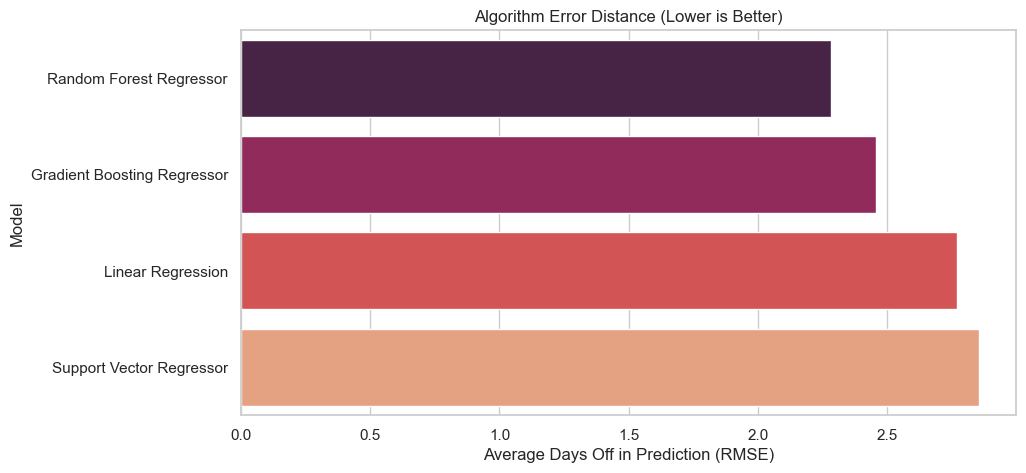

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=benchmarks, x='RMSE (Days Off)', y='Model', palette='rocket')
plt.title('Algorithm Error Distance (Lower is Better)')
plt.xlabel('Average Days Off in Prediction (RMSE)')
plt.show()

## 5. Deployment Export
Just like our classification task, we instantly extract the winning formula and package it into a `.pkl` format for the web developers to load into the API / App.

In [6]:
best_model_name = benchmarks.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"The Champion Algorithm is {best_model_name}!")

models_dir = os.path.join('models')
os.makedirs(models_dir, exist_ok=True)

export_path = os.path.join(models_dir, 'hospital_duration_model.pkl')
joblib.dump(best_model, export_path)

print(f"Success! Model dynamically exported to: {os.path.abspath(export_path)}")

The Champion Algorithm is Random Forest Regressor!
Success! Model dynamically exported to: C:\Users\rahma\Desktop\machine learning project\regression_hospital_data _set\models\hospital_duration_model.pkl
